Başarılı: Klasörde 5000 adet görsel tespit edildi. Video motoru başlatılıyor...
Otonom sürüş simülasyonu ve video üretimi başladı. Lütfen bekleyin...
Ilerleme: %0.0 işlendi...
Ilerleme: %6.0 işlendi...
Ilerleme: %12.0 işlendi...
Ilerleme: %18.0 işlendi...
Ilerleme: %24.0 işlendi...
Ilerleme: %30.0 işlendi...
Ilerleme: %36.0 işlendi...
Ilerleme: %42.0 işlendi...
Ilerleme: %48.0 işlendi...
Ilerleme: %54.0 işlendi...
Ilerleme: %60.0 işlendi...
Ilerleme: %66.0 işlendi...
Ilerleme: %72.0 işlendi...
Ilerleme: %78.0 işlendi...
Ilerleme: %84.0 işlendi...
Ilerleme: %90.0 işlendi...
Ilerleme: %96.0 işlendi...

BAŞARILI: Otonom sürüş analiz videosu 'otonom_surus_analizi.mp4' adıyla kaydedildi!


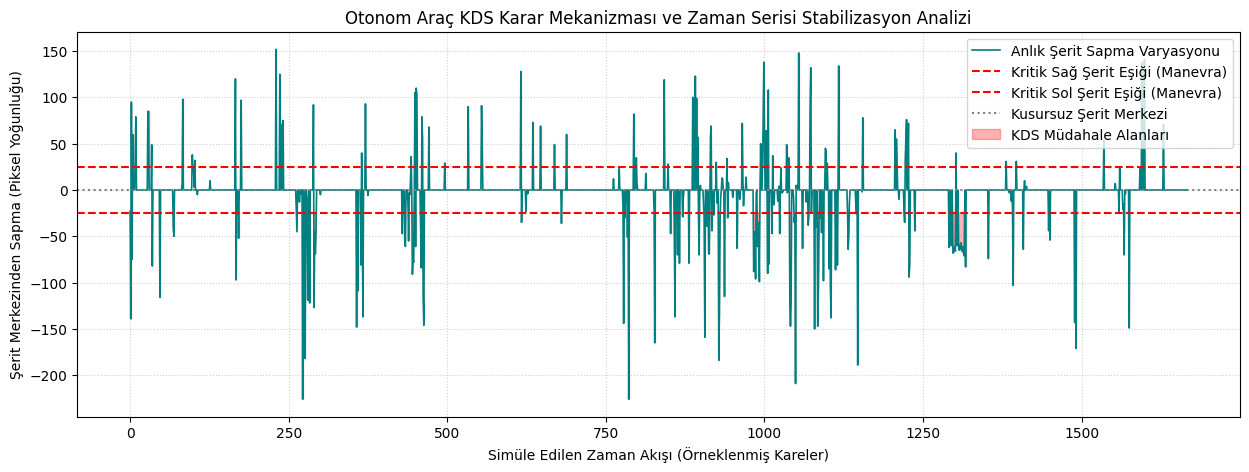

-> Makale için nihai KDS grafik çıktısı başarıyla kaydedildi.


In [4]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# --- DRIVE YOLUNU KONTROL ET ---
gorsel_klasoru = "/content/drive/MyDrive/odev_veriseti/*.jpg"
gorsel_listesi = sorted(glob.glob(gorsel_klasoru))
toplam_veri = len(gorsel_listesi)

if toplam_veri == 0:
    print("HATA: Belirtilen klasörde görsel bulunamadı! Lütfen yolu kontrol edin.")
else:
    print(f"Başarılı: Klasörde {toplam_veri} adet görsel tespit edildi. Video motoru başlatılıyor...")

# 1. İLGİ ALANI (ROI) MASKELEME
def roi_maskele(img):
    yukseklik, genislik = img.shape[:2]
    poligon = np.array([[
        (int(genislik * 0.05), yukseklik),
        (int(genislik * 0.44), int(yukseklik * 0.58)),
        (int(genislik * 0.56), int(yukseklik * 0.58)),
        (int(genislik * 0.95), yukseklik)
    ]], np.int32)
    maske = np.zeros_like(img)
    cv2.fillPoly(maske, poligon, 255)
    return cv2.bitwise_and(img, maske)

# 2. VİDEO YAZICI (VIDEO WRITER) AYARLARI
# Çıktı videosunu 640x480 boyutunda ve saniyede 20 kare (20 FPS) olacak şekilde hazırlarız
output_video_path = "otonom_surus_analizi.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_writer = cv2.VideoWriter(output_video_path, fourcc, 20.0, (640, 480))

sapma_gecmisi = []
kds_karar_gecmisi = []

# 3. KDS VE GÖRÜNTÜ İŞLEME MOTORU
print("Otonom sürüş simülasyonu ve video üretimi başladı. Lütfen bekleyin...")

# 5000 resmi çok uzun sürmemesi için her 3 resimde bir atlayarak akıcı bir video akışı simüle ediyoruz
for idx in range(0, toplam_veri, 3):
    dosya_yolu = gorsel_listesi[idx]
    frame = cv2.imread(dosya_yolu)
    if frame is None: continue
    frame = cv2.resize(frame, (640, 480))

    yukseklik, genislik = frame.shape[:2]
    gri = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gri, (5, 5), 0)
    kenarlar = cv2.Canny(blur, 50, 150)
    maskeli_kenarlar = roi_maskele(kenarlar)

    cizgiler = cv2.HoughLinesP(maskeli_kenarlar, 1, np.pi/180, 15, minLineLength=15, maxLineGap=20)

    serit_katmani = np.zeros_like(frame)
    sol_noktalar, sag_noktalar = [], []

    if cizgiler is not None:
        for cizgi in cizgiler:
            x1, y1, x2, y2 = cizgi[0]
            if x2 - x1 == 0: continue
            egim = (y2 - y1) / (x2 - x1)
            if -0.9 < egim < -0.4:
                sol_noktalar.append((x1, y1)); sol_noktalar.append((x2, y2))
            elif 0.4 < egim < 0.9:
                sag_noktalar.append((x1, y1)); sag_noktalar.append((x2, y2))

    # Varsayılan şerit merkezleri (Gürültü durumunda sistemin çökmemesi için koruma)
    sol_x, sag_x = int(genislik * 0.15), int(genislik * 0.85)

    # Sürülebilir Alan Poligon Çizimi
    if len(sol_noktalar) > 0 and len(sag_noktalar) > 0:
        sol_sirali = sorted(sol_noktalar, key=lambda x: x[1])
        sag_sirali = sorted(sag_noktalar, key=lambda x: x[1])

        sol_x = sol_sirali[-1][0]
        sag_x = sag_sirali[-1][0]

        pts = np.array([sol_sirali[0], sol_sirali[-1], sag_sirali[-1], sag_sirali[0]], np.int32).reshape((-1, 1, 2))
        cv2.fillPoly(serit_katmani, [pts], (0, 160, 80)) # Şeffaf Sürülebilir Yeşil Alan

        cv2.polylines(serit_katmani, [np.array(sol_sirali)], False, (0, 0, 255), 5) # Sol Şerit Kırmızı
        cv2.polylines(serit_katmani, [np.array(sag_sirali)], False, (255, 0, 0), 5) # Sağ Şerit Mavi

    # 4. GELİŞMİŞ SENARYO TABANLI KDS MANTIĞI
    yol_merkezi = (sol_x + sag_x) // 2
    arac_merkezi = genislik // 2
    sapma_miktari = arac_merkezi - yol_merkezi
    sapma_gecmisi.append(sapma_miktari)

    # Dinamik Senaryolar ve Aksiyon Kararları
    if sapma_miktari > 25:
        kds_durum = "SENARYO: Sol Serit Daralması -> SAG SERIDE GECIS YAPILIYOR"
        hud_renk = (0, 69, 255) # Turuncu Alarm
        direksiyon_aci = "Direksiyon: %15 Sag"
    elif sapma_miktari < -25:
        kds_durum = "SENARYO: Sagda Engel Var -> SOL SERIDE GECIS YAPILIYOR"
        hud_renk = (0, 165, 255) # Sarı Alarm
        direksiyon_aci = "Direksiyon: %15 Sol"
    elif 10 < sapma_miktari <= 25:
        kds_durum = "AKSIYON: Hafif Sola Kayma -> SERIDI ORTALA (Saga Yonlen)"
        hud_renk = (0, 255, 255)
        direksiyon_aci = "Direksiyon: %5 Sag"
    elif -25 <= sapma_miktari < -10:
        kds_durum = "AKSIYON: Hafif Saga Kayma -> SERIDI ORTALA (Sola Yonlen)"
        hud_renk = (0, 255, 255)
        direksiyon_aci = "Direksiyon: %5 Sol"
    else:
        kds_durum = "SISTEM OPTIMIZED: Serit Merkezlendi -> Otopilot Aktif"
        hud_renk = (0, 180, 0) # Güvenli Yeşil
        direksiyon_aci = "Direksiyon: %0 (Düz)"

    kds_karar_gecmisi.append(kds_durum)

    # Orijinal Görüntü ile Maskeyi Birleştirma
    final_frame = cv2.addWeighted(frame, 0.8, serit_katmani, 0.4, 0)

    # İdeal Rota Kılavuz Çizgisi (Trajectory Path) Çizimi
    cv2.line(final_frame, (yol_merkezi, yukseklik), (genislik // 2, int(yukseklik * 0.6)), (255, 255, 255), 2, lineType=cv2.LINE_AA)

    # 5. ENDÜSTRİYEL KOKPİT HUD PANEL TASARIMI
    cv2.rectangle(final_frame, (0, 0), (640, 65), (20, 20, 20), -1) # Üst Kara Bar
    cv2.line(final_frame, (0, 65), (640, 65), (100, 100, 100), 1)

    cv2.putText(final_frame, f"TELEMETRI | FRAME: {idx:04d}", (15, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
    cv2.putText(final_frame, f"SAPMA INDEKSI: {sapma_miktari:+.1f} px", (15, 48), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 200, 200), 1)
    cv2.putText(final_frame, direksiyon_aci, (220, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

    # Dinamik Karar Kutusu
    cv2.rectangle(final_frame, (350, 15), (625, 48), hud_renk, -1)
    cv2.putText(final_frame, "KDS AKILLI MANEVRA SEKTORU", (355, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 255, 255), 1)
    cv2.putText(final_frame, kds_durum.split(" -> ")[-1] if " -> " in kds_durum else kds_durum, (355, 42), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1, cv2.LINE_AA)

    # Videoya Yeni Kareyi Yazdır
    video_writer.write(final_frame)

    # Konsola her 100 karede bir ilerleme durumunu bas
    if idx % 300 == 0:
        print(f"Ilerleme: %{(idx / toplam_veri) * 100:.1f} işlendi...")

video_writer.release()
print("\nBAŞARILI: Otonom sürüş analiz videosu 'otonom_surus_analizi.mp4' adıyla kaydedildi!")

# 6. AKADEMİK PERFORMANS GRAFİĞİ (MANEVRA VE TEPKİ SÜRELERİ)
plt.figure(figsize=(15, 5))
plt.plot(sapma_gecmisi, color='teal', linewidth=1.2, label='Anlık Şerit Sapma Varyasyonu')
plt.axhline(y=25, color='r', linestyle='--', label='Kritik Sağ Şerit Eşiği (Manevra)')
plt.axhline(y=-25, color='r', linestyle='--', label='Kritik Sol Şerit Eşiği (Manevra)')
plt.axhline(y=0, color='gray', linestyle=':', label='Kusursuz Şerit Merkezi')
plt.fill_between(range(len(sapma_gecmisi)), sapma_gecmisi, 25, where=(np.array(sapma_gecmisi) > 25), color='red', alpha=0.3, label='KDS Müdahale Alanları')
plt.fill_between(range(len(sapma_gecmisi)), sapma_gecmisi, -25, where=(np.array(sapma_gecmisi) < -25), color='red', alpha=0.3)
plt.title("Otonom Araç KDS Karar Mekanizması ve Zaman Serisi Stabilizasyon Analizi")
plt.xlabel("Simüle Edilen Zaman Akışı (Örneklenmiş Kareler)")
plt.ylabel("Şerit Merkezinden Sapma (Piksel Yoğunluğu)")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("kds_nihai_performans_grafigi.png", dpi=300)
plt.show()
print("-> Makale için nihai KDS grafik çıktısı başarıyla kaydedildi.")